# ECOv003 JET Accuracy Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data. 

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the JET ensemble, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [138]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed, sensitivity_magnitude_barchart
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Configuration Options

Set configuration options for the notebook, including whether to save plots to files.

In [139]:
# Configuration: Set to True to save plots to files, False to only display them
SAVE_PLOTS = False

In [140]:
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
    "AOT",
    "COT",
    "vapor_gccm",
    "ozone_cm",
    "elevation_m",
    "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    # "ST_C": 0.0,
    # "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0,
}

input_max = {
    # "ST_C": 50.0,
    # "ST_C": 60.0,
    # "NDVI": 1,
    "albedo": 1,
}

## Define Processing Function for Model Table

This cell defines the forward process for analysis as the BESS-JPL model.

In [141]:
forward_process = process_JET_table
model_name = "JET"

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [142]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out surface temperatures greater than 50 Celsius and NDVI values less than 0.05. The resulting DataFrame is displayed for inspection.

In [143]:
input_raw_df = load_ECOv002_calval_JET_inputs()
processed_raw_df = forward_process(input_raw_df)
processed_raw_df

[2026-08-12 11:38:55 INFO] starting JET table processing
[2026-08-12 11:38:55 INFO] started extracting geometry from JET input table
[2026-08-12 11:38:55 INFO] completed extracting geometry from JET input table (0.009 seconds)
[2026-08-12 11:38:55 INFO] started extracting time from JET input table
[2026-08-12 11:38:55 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-12 11:38:55 INFO] running Forest Light Environmental Simulator
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[2026-08-12 11:38:55 INFO] completed processing FLiES-ANN in 0.20 seconds
[2026-08-12 11:38:55 INFO] variable PAR_albedo min: 0.003 mean: 0.052 max: 0.681 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable NIR_albedo min: 0.028 mean: 0.164 max: 0.582 nan: 0.00% (nan)


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-12 11:38:55 INFO] variable PAR_direct_Wm2 min: 4.617 mean: 266.198 max: 473.257 nan: 0.38% (nan)
[2026-08-12 11:38:55 INFO] variable SWin_FLiES_ANN min: 104.662 mean: 715.359 max: 1153.185 nan: 0.38% (nan)
[2026-08-12 11:38:55 INFO] running Breathing Earth System Simulator
<class 'numpy.ndarray'>
float32
[2026-08-12 11:38:55 INFO] variable SZA_deg min: 8.815 mean: 44.939 max: 72.288 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable CI min: 0.184 mean: 0.278 max: 1.000 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable elevation_m min: 1.000 mean: 992.883 max: 3504.000 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable C4_fraction min: 0.000 mean: 0.296 max: 0.939 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable carbon_uptake_efficiency min: 0.080 mean: 0.083 max: 0.090

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-12 11:38:55 INFO] variable Ms min: 0.000 mean: 0.229 max: 1.000 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] running STIC iteration 1 / 3
[2026-08-12 11:38:55 INFO] using variable Priestley-Taylor alpha with mean: 1.264
[2026-08-12 11:38:55 INFO] completed STIC iteration 1 / 3 with max LE change: 316.084 (0.0021891250216867775 seconds)
[2026-08-12 11:38:55 INFO] variable SM_1 min: 0.000 mean: 0.143 max: 1.000 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] variable G_1 min: 0.000 mean: 65.311 max: 222.087 nan: 0.56% (nan)
[2026-08-12 11:38:55 INFO] variable LE_1 min: 0.000 mean: 248.988 max: 746.899 nan: 0.56% (nan)
[2026-08-12 11:38:55 INFO] running STIC iteration 2 / 3
[2026-08-12 11:38:55 INFO] using variable Priestley-Taylor alpha with mean: 1.535
[2026-08-12 11:38:55 INFO] completed STIC iteration 2 / 3 with max LE change: 91.852 (0.006413333001546562 seconds)
[2026-08-12 11:38:55 INFO] variable SM_2 min: 0.000 mean: 0.146 max: 1.000 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO]

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

[2026-08-12 11:38:55 INFO] variable ET_daylight_kg min: 0.000 mean: 2.363 max: 7.164 nan: 0.00% (nan)
[2026-08-12 11:38:55 INFO] JET table processing complete (0.691 seconds)


,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,60.425858,60.425858,351.448461,351.448461,54.761772,4.144935,0.773774,0.000212,0.000109,1.943556
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,99.328964,99.328964,326.039533,326.039533,360.706912,4.279363,1.239315,0.000269,0.000111,2.421845
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,94.519459,94.519459,335.227018,335.227018,306.110166,4.353823,0.920482,0.000251,0.000044,5.670131
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,78.277108,78.277108,332.815927,332.815927,345.610073,4.433066,0.372526,0.000303,0.000049,6.158837
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,70.628272,70.628272,290.934683,290.934683,260.113128,4.244395,0.368856,0.000283,0.000058,4.846558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,5.985290,5.985290,35.172963,35.172963,196.977862,0.423263,0.427738,0.000006,0.000008,0.723558
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,23.006292,23.006292,37.569782,37.569782,187.016966,0.815033,1.326901,0.000015,0.000012,1.260016
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,43.185134,43.185134,27.267394,27.267394,258.399557,0.585193,0.710205,0.000041,0.000031,1.332510
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,28.164664,28.164664,58.151032,58.151032,265.153028,1.076440,0.606770,0.000024,0.000023,1.048858


In [144]:
for variable_name, minimum_value in input_min.items():
    print(f"{variable_name} min: {minimum_value}")
    print(len(input_raw_df[input_raw_df[variable_name] < minimum_value]), "rows below min")

albedo min: 0.0
0 rows below min
Ta_C min: 0.0
17 rows below min
RH min: 0.0
0 rows below min
AOT min: 0.0
0 rows below min
COT min: 0.0
0 rows below min
vapor_gccm min: 0.0
0 rows below min
ozone_cm min: 0.0
0 rows below min
elevation_m min: 0.0
0 rows below min
canopy_height_meters min: 0.0
0 rows below min


In [145]:
for variable_name, maximum_value in input_max.items():
    print(f"{variable_name} max: {maximum_value}")
    print(len(input_raw_df[input_raw_df[variable_name] > maximum_value]), "rows above max")
    print(", ".join(sorted(input_raw_df[input_raw_df[variable_name] > maximum_value][variable_name].astype(str).tolist())))

albedo max: 1
0 rows above max



In [146]:
input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,2.58,0.4060,0.32,0.14
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,8.48,0.4017,0.29,0.12


In [147]:
processed_raw_df["filtered"] = mask
processed_raw_df.filtered

0       True
1       True
2       True
3       True
4       True
        ... 
1060    True
1061    True
1062    True
1063    True
1064    True
Name: filtered, Length: 1065, dtype: bool

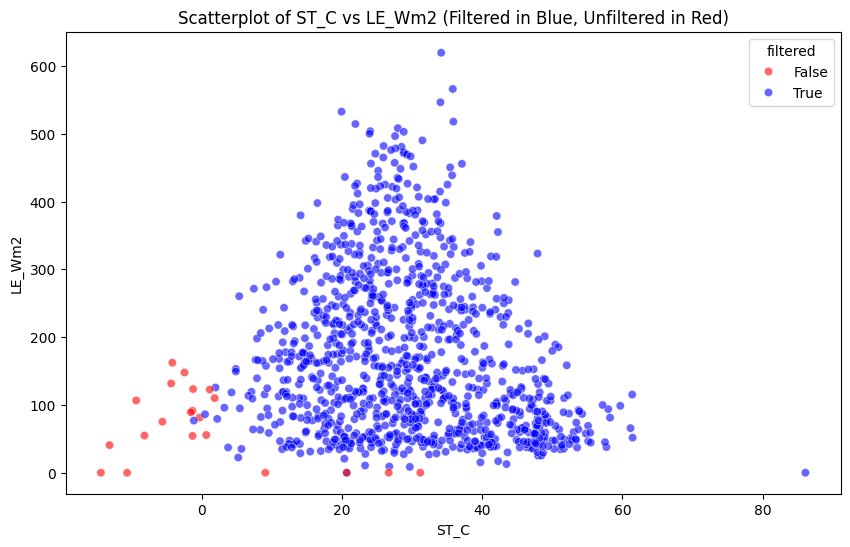

In [148]:
#scatterplot of process_raw_df["ST_C"] vs processed_raw_df["LE_Wm2"] colored by processed_raw_df["filtered"]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=processed_raw_df, x="ST_C", y="LE_Wm2", hue="filtered", palette={True: "blue", False: "red"}, alpha=0.6)
plt.title("Scatterplot of ST_C vs LE_Wm2 (Filtered in Blue, Unfiltered in Red)")
plt.xlabel("ST_C")
plt.ylabel("LE_Wm2")
plt.show()

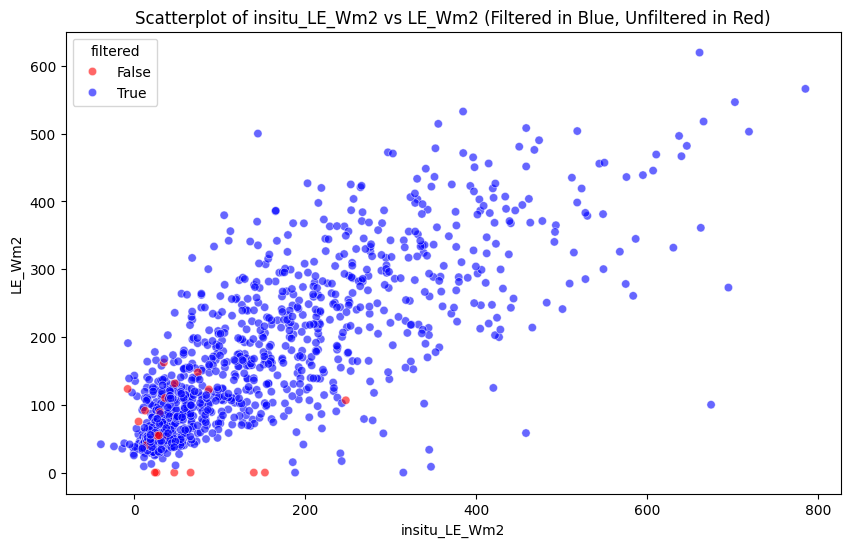

In [149]:
#scatterplot of process_raw_df["insitu_LE_Wm2"] vs processed_raw_df["LE_Wm2"] colored by processed_raw_df["filtered"]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=processed_raw_df, x="insitu_LE_Wm2", y="LE_Wm2", hue="filtered", palette={True: "blue", False: "red"}, alpha=0.6)
plt.title("Scatterplot of insitu_LE_Wm2 vs LE_Wm2 (Filtered in Blue, Unfiltered in Red)")
plt.xlabel("insitu_LE_Wm2")
plt.ylabel("LE_Wm2")
plt.show()

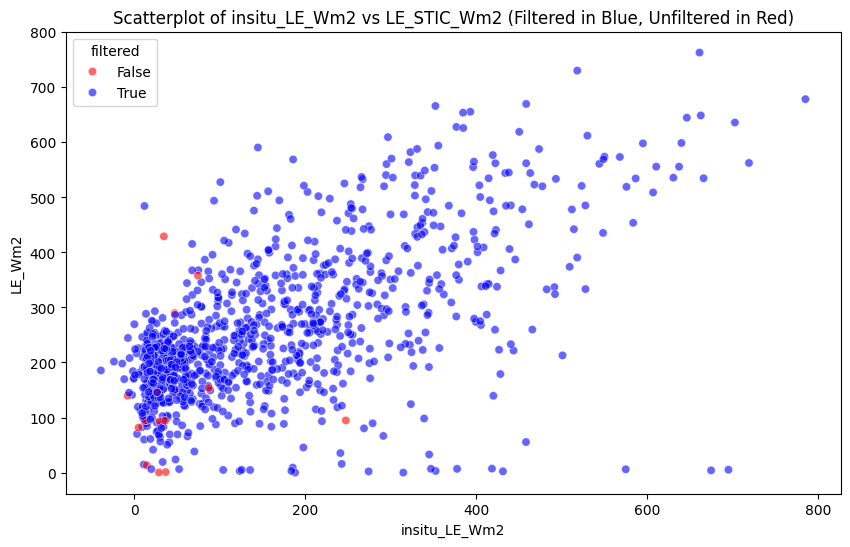

In [150]:
#scatterplot of process_raw_df["insitu_LE_Wm2"] vs processed_raw_df["LE_Wm2"] colored by processed_raw_df["filtered"]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=processed_raw_df, x="insitu_LE_Wm2", y="LE_STIC_Wm2", hue="filtered", palette={True: "blue", False: "red"}, alpha=0.6)
plt.title("Scatterplot of insitu_LE_Wm2 vs LE_STIC_Wm2 (Filtered in Blue, Unfiltered in Red)")
plt.xlabel("insitu_LE_Wm2")
plt.ylabel("LE_Wm2")
plt.show()

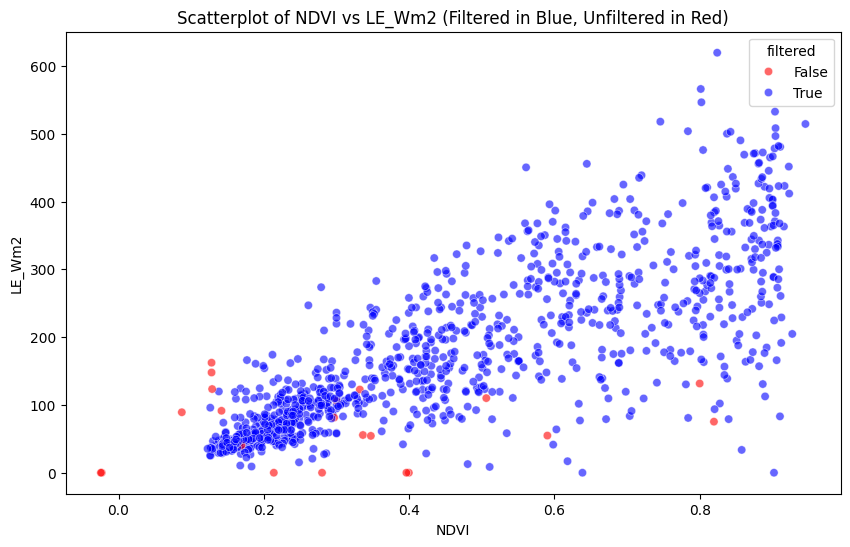

In [151]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=processed_raw_df, x="NDVI", y="LE_Wm2", hue="filtered", palette={True: "blue", False: "red"}, alpha=0.6)
plt.title("Scatterplot of NDVI vs LE_Wm2 (Filtered in Blue, Unfiltered in Red)")
plt.xlabel("NDVI")
plt.ylabel("LE_Wm2")
plt.show()

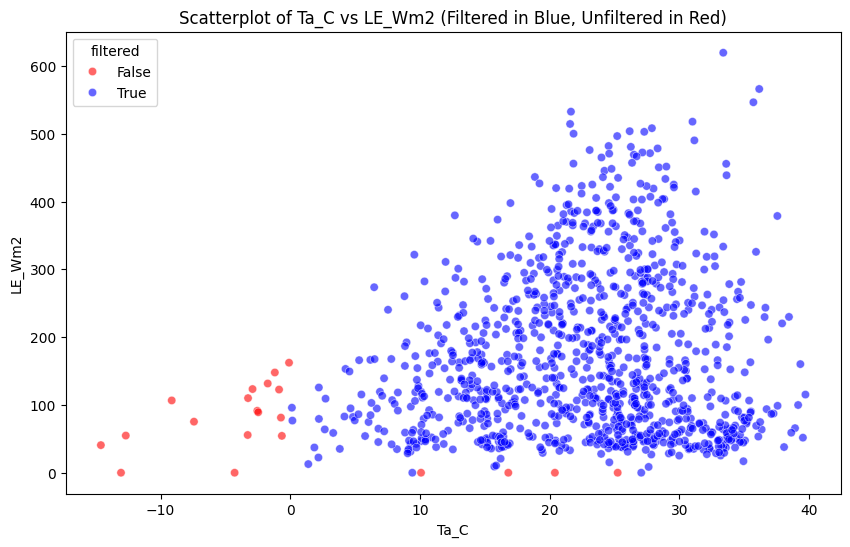

In [152]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=processed_raw_df, x="Ta_C", y="LE_Wm2", hue="filtered", palette={True: "blue", False: "red"}, alpha=0.6)
plt.title("Scatterplot of Ta_C vs LE_Wm2 (Filtered in Blue, Unfiltered in Red)")
plt.xlabel("Ta_C")
plt.ylabel("LE_Wm2")
plt.show()

In [153]:
input_df = input_raw_df

## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the model, and displays the resulting DataFrame.

In [154]:
processed = forward_process(input_df)
processed

[2026-08-12 11:38:56 INFO] starting JET table processing
[2026-08-12 11:38:56 INFO] started extracting geometry from JET input table
[2026-08-12 11:38:56 INFO] completed extracting geometry from JET input table (0.015 seconds)
[2026-08-12 11:38:56 INFO] started extracting time from JET input table
[2026-08-12 11:38:56 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-12 11:38:56 INFO] running Forest Light Environmental Simulator
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[2026-08-12 11:38:56 INFO] completed processing FLiES-ANN in 0.20 seconds


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-12 11:38:56 INFO] variable PAR_albedo min: 0.003 mean: 0.052 max: 0.681 nan: 0.00% (nan)
[2026-08-12 11:38:56 INFO] variable NIR_albedo min: 0.028 mean: 0.164 max: 0.582 nan: 0.00% (nan)
[2026-08-12 11:38:56 INFO] variable PAR_direct_Wm2 min: 4.617 mean: 266.198 max: 473.257 nan: 0.38% (nan)
[2026-08-12 11:38:56 INFO] variable SWin_FLiES_ANN min: 104.662 mean: 715.359 max: 1153.185 nan: 0.38% (nan)
[2026-08-12 11:38:56 INFO] running Breathing Earth System Simulator
<class 'numpy.ndarray'>
float32
[2026-08-12 11:38:56 INFO] variable SZA_deg min: 8.815 mean: 44.939 max: 72.288 nan: 0.00% (nan)
[2026-08-12 11:38:56 INFO] variable CI min: 0.184 mean: 0.278 max: 1.000 nan: 0.00% (nan)
[2026-08-12 11:38:56 INFO] variable elevation_m min: 1.000 mean: 992.883 max: 3504.000 nan: 0.00% (nan)
[2026-08-12 11:38:56 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2026-08-12 11:38:56 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (na

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-12 11:38:56 INFO] variable LE_3 min: 0.000 mean: 254.365 max: 762.748 nan: 0.56% (nan)
[2026-08-12 11:38:56 INFO] started daily ET upscaling (STIC-JPL)
[2026-08-12 11:38:56 INFO] completed daily ET upscaling (elapsed: 0.02 seconds)
[2026-08-12 11:38:56 INFO] completed processing STIC-JPL in 0.06 seconds
[2026-08-12 11:38:56 INFO] variable LE_STIC_Wm2 min: 0.000 mean: 254.365 max: 762.748 nan: 0.56% (nan)
[2026-08-12 11:38:56 INFO] variable ET_daylight_STIC_kg min: 0.000 mean: 3.524 max: 8.821 nan: 0.56% (nan)
[2026-08-12 11:38:56 INFO] variable LE_canoy_STIC_Wm2 min: 0.000 mean: 184.142 max: 569.703 nan: 0.56% (nan)
[2026-08-12 11:38:56 INFO] variable G_STIC_Wm2 min: 0.000 mean: 65.311 max: 222.087 nan: 0.56% (nan)
[2026-08-12 11:38:56 INFO] variable LE_canopy_fraction_STIC min: 0.000 mean: 0.737 max: 1.000 nan: 0.56% (nan)
[2026-08-12 11:38:56 INFO] running Priestley-Taylor JPL with Soil Moisture
[2026-08-12 11:38:56 INFO] starting PT-JPL-SM model run
[2026-08-12 11:38:56 INF

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Use

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,60.425858,60.425858,351.448461,351.448461,54.761772,4.144935,0.773774,0.000212,0.000109,1.943556
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,99.328964,99.328964,326.039533,326.039533,360.706912,4.279363,1.239315,0.000269,0.000111,2.421845
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,94.519459,94.519459,335.227018,335.227018,306.110166,4.353823,0.920482,0.000251,0.000044,5.670131
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,78.277108,78.277108,332.815927,332.815927,345.610073,4.433066,0.372526,0.000303,0.000049,6.158837
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,70.628272,70.628272,290.934683,290.934683,260.113128,4.244395,0.368856,0.000283,0.000058,4.846558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,5.985290,5.985290,35.172963,35.172963,196.977862,0.423263,0.427738,0.000006,0.000008,0.723558
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,23.006292,23.006292,37.569782,37.569782,187.016966,0.815033,1.326901,0.000015,0.000012,1.260016
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,43.185134,43.185134,27.267394,27.267394,258.399557,0.585193,0.710205,0.000041,0.000031,1.332510
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,28.164664,28.164664,58.151032,58.151032,265.153028,1.076440,0.606770,0.000024,0.000023,1.048858


## Accuracy Comparison of In-Situ Observations to Model Estimates

Examining the accuracy of model estimates compared to ground data.

analyzing JET accuracy for ET_daylight_kg compared to insitu_ET_daylight_kg


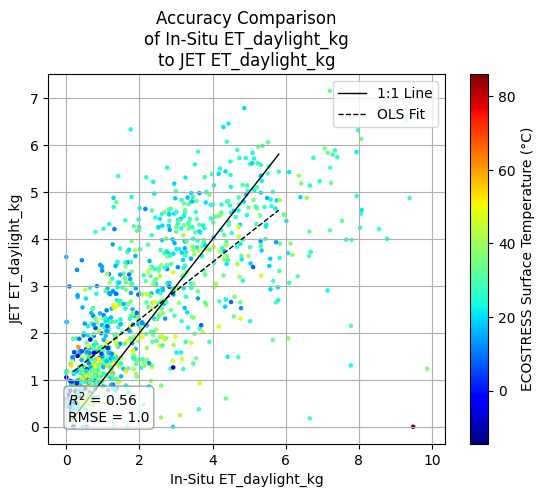

analyzing JET accuracy for G_Wm2 compared to insitu_G_Wm2


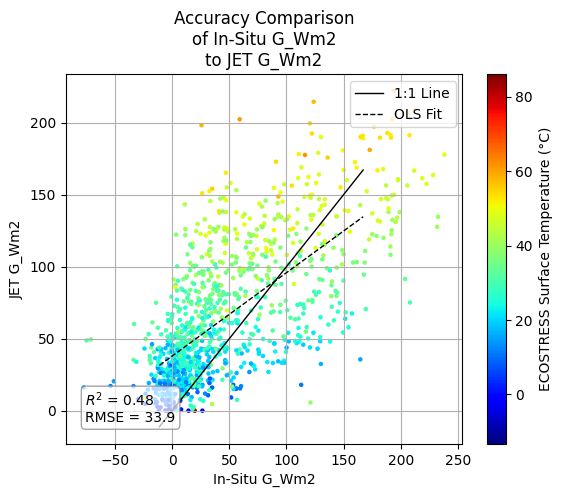

analyzing JET accuracy for H_Wm2 compared to insitu_H_Wm2


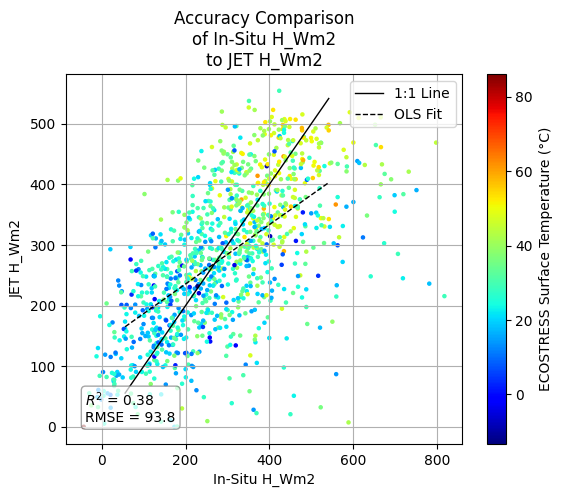

analyzing JET accuracy for LE_Wm2 compared to insitu_LE_Wm2


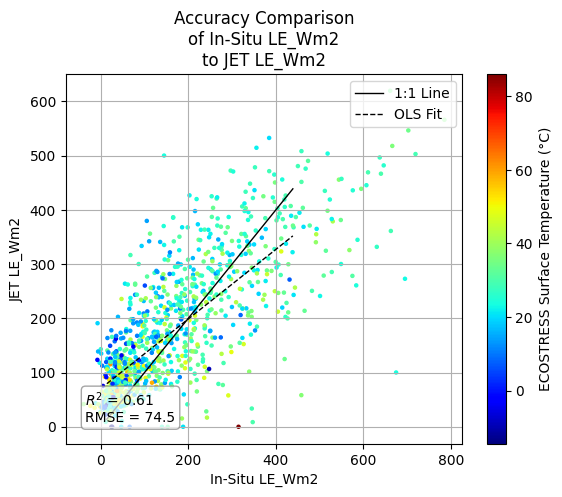

analyzing JET accuracy for LE_daylight_Wm2 compared to insitu_LE_daylight_Wm2
Error processing LE_daylight_Wm2: "['LE_daylight_Wm2'] not in index"
analyzing JET accuracy for RH compared to insitu_RH


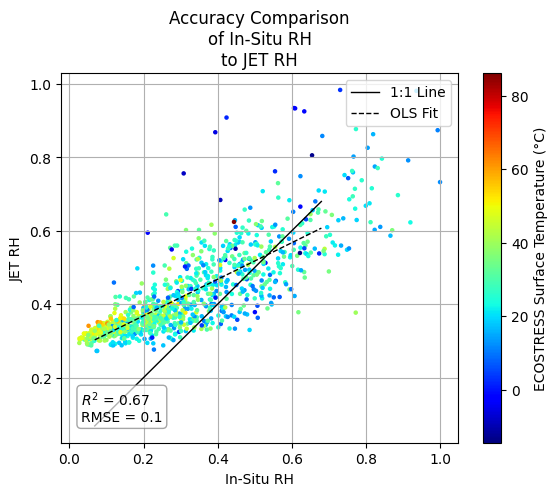

analyzing JET accuracy for Rn_Wm2 compared to insitu_Rn_Wm2


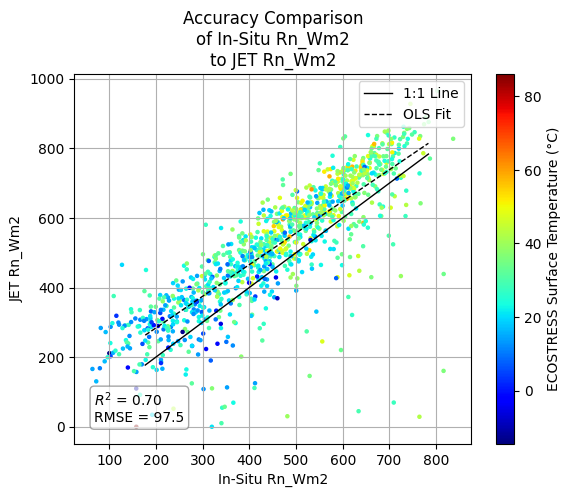

analyzing JET accuracy for Rn_daylight_Wm2 compared to insitu_Rn_daylight_Wm2
Error processing Rn_daylight_Wm2: "['Rn_daylight_Wm2'] not in index"
analyzing JET accuracy for SWin_Wm2 compared to insitu_SWin_Wm2


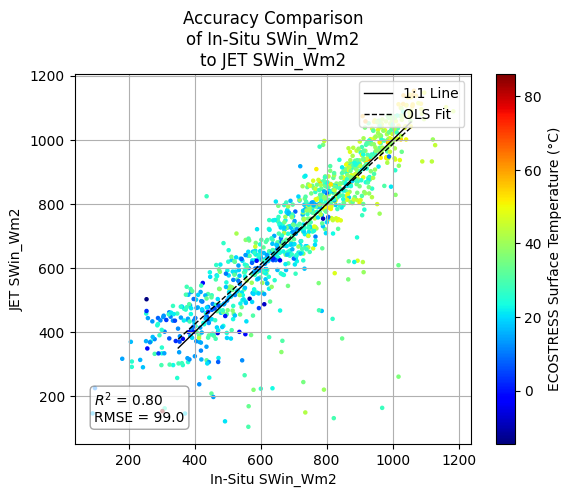

analyzing JET accuracy for Ta_C compared to insitu_Ta_C


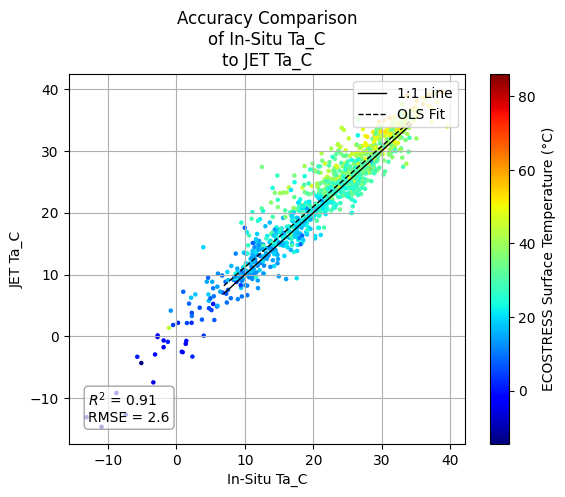

In [155]:
insitu_columns = sorted([column for column in processed.columns if "insitu" in column])

for insitu_variable in insitu_columns:
    try:
        output_variable = insitu_variable.replace("insitu_", "")
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {output_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

# Accuracy Comparison for Net Radiation between BESS and Verma

analyzing JET accuracy for Rn_BESS_Wm2 compared to insitu_Rn_Wm2


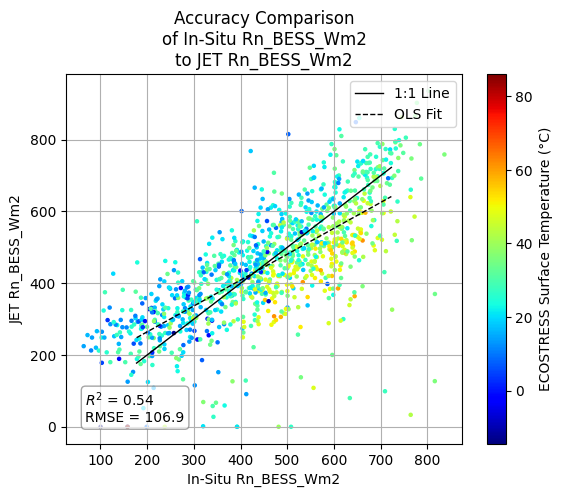

analyzing JET accuracy for Rn_verma_Wm2 compared to insitu_Rn_Wm2


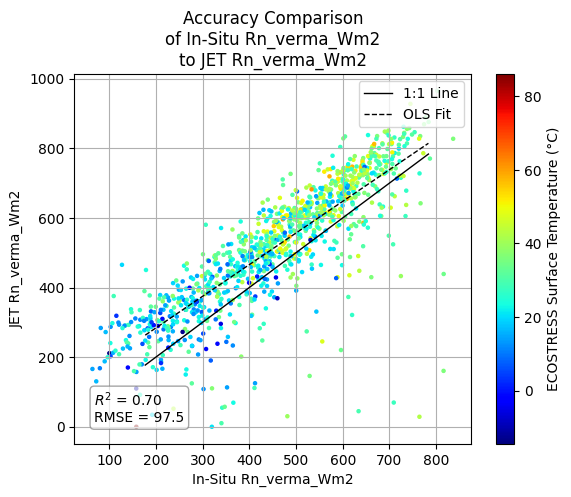

In [156]:
insitu_variable = "insitu_Rn_Wm2"

for output_variable in ["Rn_BESS_Wm2", "Rn_verma_Wm2"]:
    try:
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {output_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

analyzing JET accuracy for LE_BESS_Wm2 compared to insitu_LE_Wm2


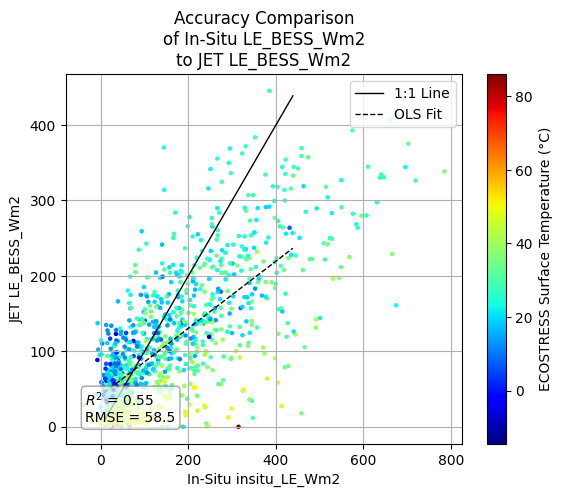

analyzing JET accuracy for LE_STIC_Wm2 compared to insitu_LE_Wm2


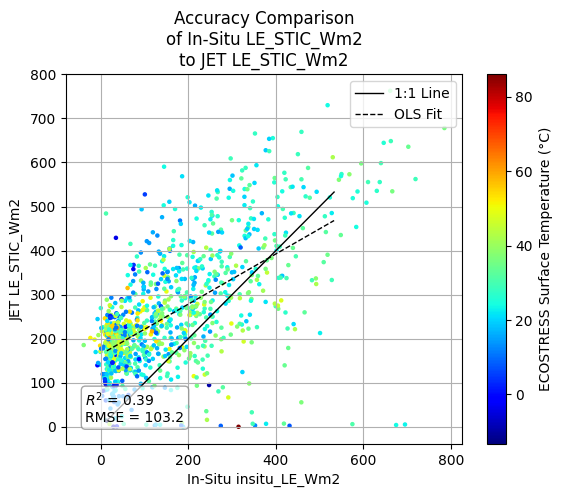

analyzing JET accuracy for LE_PTJPLSM_Wm2 compared to insitu_LE_Wm2


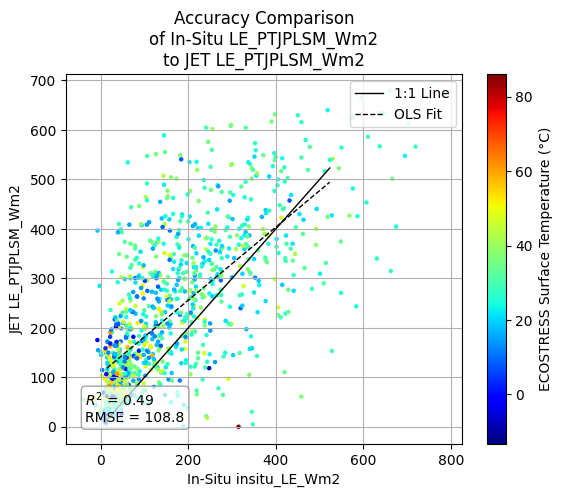

analyzing JET accuracy for LE_PMJPL_Wm2 compared to insitu_LE_Wm2


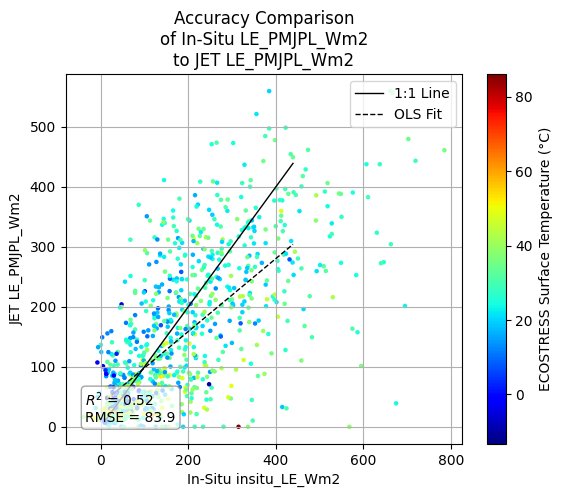

analyzing JET accuracy for LE_Wm2 compared to insitu_LE_Wm2


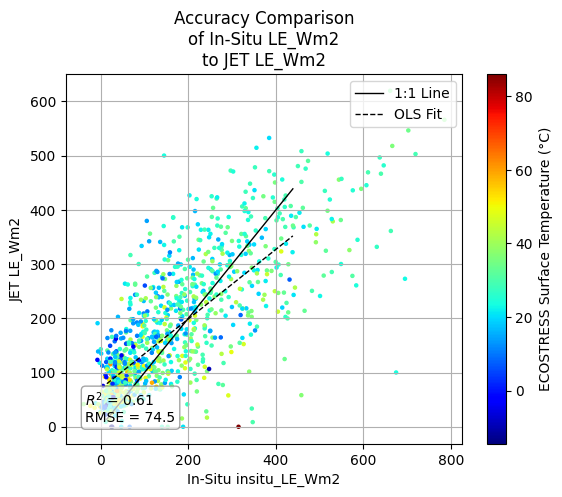

In [157]:
insitu_variable = "insitu_LE_Wm2"

output_variables = [
    "LE_BESS_Wm2",
    "LE_STIC_Wm2",
    "LE_PTJPLSM_Wm2",
    "LE_PMJPL_Wm2",
    "LE_Wm2"
]

for output_variable in output_variables:
    try:
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {insitu_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue


## Plot Unperturbed Comparison of Surface Temperature to Net Radiation

This cell creates a scatter plot comparing ECOSTRESS surface temperature to net radiation for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

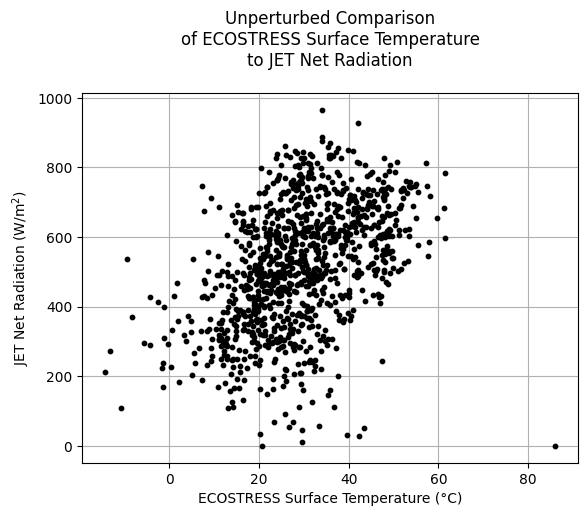

In [158]:
plt.scatter(x=processed.ST_C, y=processed.Rn_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel(f"{model_name} Net Radiation (W/m$^2$)")
plt.title(f"Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto {model_name} Net Radiation", pad=20)

if SAVE_PLOTS:
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Evapotranspiration

This cell creates a scatter plot comparing ECOSTRESS surface temperature to BESS-JPL evapotranspiration for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

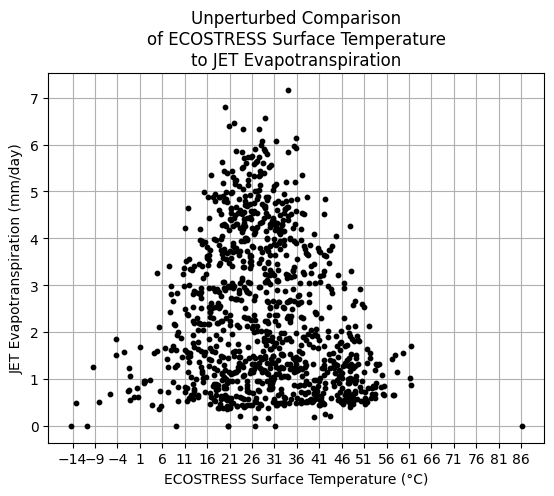

In [159]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.ET_daylight_kg, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel(f"{model_name} Evapotranspiration (mm/day)")
plt.title(f"Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto {model_name} Evapotranspiration")

if SAVE_PLOTS:
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()

In [160]:
processed.sample(n=10)

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
637,637,US-SRG,GRA,Bsk,131.368260,0.00000,118.706085,44.667767,79.107109,53.788820,...,102.314260,102.314260,38.328158,38.328158,435.708899,0.501382,0.992833,0.000009,0.000021,0.424759
743,743,US-MMS,DBF,Cfa,2.156185,641.36320,537.584100,365.326260,NaN,246.333680,...,25.021066,25.021066,368.664142,368.664142,175.325936,4.827943,1.642692,0.000401,0.000116,3.447472
302,302,US-UMd,DBF,Dfb,91.529366,166.65631,124.274710,79.613280,109.761536,33.774340,...,11.538135,11.538135,109.614046,109.614046,44.951468,2.805606,0.842670,0.000186,0.000013,10.000000
419,419,US-SP1,ENF,Cfa,135.852480,89.76537,202.536420,105.762240,174.386566,43.412285,...,20.329356,20.329356,162.097201,162.097201,75.860433,2.185144,0.485819,0.000122,0.000039,3.105351
969,969,US-Rwf,CSH,Bsh,415.409580,169.93800,413.447540,232.087230,66.809891,108.949010,...,115.227144,115.227144,266.421034,266.421034,452.472163,3.326558,1.758310,0.000212,0.000120,1.762165
790,790,US-xSB,ENF,Cfa,259.811130,205.74681,517.698300,343.077100,411.320984,119.077194,...,75.905356,75.905356,262.016769,262.016769,287.416037,2.514369,0.623510,0.000224,0.000082,2.731447
647,647,US-SRG,GRA,Bsk,4.219351,1000.00000,264.347560,115.991420,190.820740,388.640750,...,62.219919,62.219919,140.069267,140.069267,317.808918,1.444993,0.456760,0.000125,0.000062,2.037445
169,169,US-Whs,OSH,Bsk,47.927994,0.00000,87.745170,35.291750,52.508411,32.447370,...,104.069697,104.069697,36.005323,36.005323,455.716026,0.482104,0.979732,0.000003,0.000017,0.196410
642,642,US-SRG,GRA,Bsk,167.530400,0.00000,86.145970,35.905780,59.658134,62.765045,...,88.536093,88.536093,29.983491,29.983491,296.990617,0.596144,1.398528,0.000001,0.000017,0.077387
584,584,US-xJE,ENF,Cfa,159.106000,146.13268,316.655270,209.586140,248.480835,67.382160,...,23.868127,23.868127,286.814297,286.814297,103.484992,5.117368,0.851897,0.000265,0.000097,2.743618


In [161]:
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.0070,12.02,-8.0,650.0,4500.0,32.65892,10.09,0.4659,0.24,0.11
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13


In [162]:
load_ECOv002_calval_JET_inputs()

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.0070,12.02,-8.0,650.0,4500.0,32.65892,10.09,0.4659,0.24,0.11
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.0065,11.39,-8.0,650.0,3500.0,20.56636,1.39,0.4865,0.31,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,NaN,NaN,NaN,NaN,NaN,NaN,7.99,0.3387,0.28,0.13


In [163]:
for column in load_ECOv002_calval_JET_inputs().columns:
    print(column)

Unnamed: 0
ID
vegetation
climate
STICinst
BESSinst
MOD16inst
PTJPLSMinst
ETinst
ETinstUncertainty
PET
Rn
ESI
RH
Ta
LST
SM
NDVI
NDVI-UQ
albedo
albedo-UQ
LST_err
view_zenith
Rg
EmisWB
time_utc
solar_time
solar_hour
local_time
LE
LE_filt
LEcorr25
LEcorr50
LEcorr75
LEcorr_ann
H_filt
Hcorr25
Hcorr50
Hcorr75
Hcorr_ann
NETRAD_filt
G_filt
SM_surf
SM_rz
AirTempC
SW_IN
RH_percentage
ESIrn_STIC
ESIrn_PTJPLSM
ESIrn_MOD16
ESIrn_BESS
ESIrn_Unc_ECO
ESIrn_LEcorr50
JET
eco_time_utc
Site Name
Date-Time
Site ID
Name
Lat
Long
Elev
Clim
Veg
MAT
MAP
StartDate
EndDate
LE_count
closure_ratio
geometry
elevation_m
time_UTC
ST_K
ST_C
Ta_C
SWin_Wm2
emissivity
orbit
scene
tile
insitu_LE_Wm2
insitu_H_Wm2
insitu_Rn_Wm2
insitu_G_Wm2
insitu_SWin_Wm2
insitu_Ta_C
insitu_RH
insitu_Rn_daylight_Wm2
insitu_LE_daylight_Wm2
insitu_ET_daylight_kg
date_UTC
SZA_deg
KG_climate
COT
AOT
vapor_gccm
ozone_cm
name
NDVI_minimum
NDVI_maximum
C4_fraction
carbon_uptake_efficiency
kn
peakVCmax_C3
peakVCmax_C4
ball_berry_slope_C3
ball_berry

In [164]:
sample_df = processed.dropna().sample(10)
sample_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
43,43,US-Me6,ENF,Csb,124.918360,116.59763,228.623030,105.745300,197.370804,48.805360,...,28.131712,28.131712,125.513288,125.513288,148.989632,2.764752,0.550632,1.020703e-04,0.000037,2.791465
518,518,US-Syv,MF,Dfb,258.901000,165.96100,425.055080,253.538010,81.899628,92.898670,...,43.100230,43.100230,248.555729,248.555729,219.190932,3.557864,1.357886,1.962378e-04,0.000111,1.767325
129,129,US-Whs,OSH,Bsk,216.645740,0.00000,181.399540,89.483860,173.851135,84.276470,...,149.376776,149.376776,78.997839,78.997839,472.716071,1.124766,0.843153,2.537743e-06,0.000046,0.054691
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.514800,405.504970,366.056641,222.890230,...,33.327171,33.327171,342.565013,342.565013,348.501129,4.442026,0.971980,2.905200e-04,0.000122,2.390822
153,153,US-Whs,OSH,Bsk,187.682720,187.72745,121.415726,53.090760,52.367222,55.298100,...,167.756949,167.756949,47.826609,47.826609,507.559159,0.605478,0.720192,3.904672e-07,0.000027,0.014291
144,144,US-Whs,OSH,Bsk,76.523060,319.81766,109.262450,46.734135,64.525879,107.436340,...,86.994536,86.994536,49.897493,49.897493,425.866975,0.513508,0.723194,1.856690e-05,0.000023,0.795781
297,297,US-Rls,CSH,Bsh,67.170510,87.14500,240.183470,109.534250,193.642670,66.373024,...,72.563200,72.563200,114.333084,114.333084,320.025568,1.981312,0.689669,1.019512e-04,0.000055,1.866627
85,85,US-Me6,ENF,Csb,48.174110,98.16507,223.277040,88.979070,215.325912,65.363075,...,33.280291,33.280291,92.354573,92.354573,192.974369,0.882422,0.133901,1.049630e-04,0.000037,2.827893
131,131,US-Whs,OSH,Bsk,194.795840,0.00000,115.911190,61.257940,96.341553,71.748480,...,111.931413,111.931413,53.484190,53.484190,317.770084,1.010891,1.361341,1.006253e-06,0.000032,0.031691
149,149,US-Whs,OSH,Bsk,226.658370,178.11351,121.983055,55.959164,72.384293,63.637756,...,159.915342,159.915342,47.352873,47.352873,482.654078,0.569669,0.850513,3.667603e-07,0.000028,0.012931


In [165]:
sample_df.to_csv("sample_df.csv", index=False)